### GeoIndex EDA: CIMC Data

### Initialize

- Libraries
- GDB Path
- Load layers with fiona

In [ ]:
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as cx
import pandas as pd

In [ ]:
gdb_path = "Data\Cleanups.gdb"

available_layers = fiona.listlayers(gdb_path)
print("Available layers:", available_layers)

Available layers: ['CIMC_sites', 'Brownfields_Grant_Jurisdictions', 'Brownfields_Grant_Data', 'CIMC_Sites_Alternative_Names']


## Layer Summary

This function:
- Outputs the layer shape
- Outputs info on columns & types
- Heads the data
- Outputs geometry type
- Outputs summary stats

In [ ]:
#Performs basic EDA for a layer in the geodatabase
def layer_summary(layer_gdf):

    print("----- Layer Summary -----")

    #Basic info
    print("Shape (Rows, Columns)")
    print(layer_gdf.shape)

    print("Data columns & types")
    print(layer_gdf.columns)
    layer_gdf.info()

    display(layer_gdf.head())

    #Geometry 
    if 'geometry' in layer_gdf.columns:
        print("\n --- Geospatial Info ---")
        print(f"Geometry Type: {layer_gdf.geometry.geom_type.unique()}")
        print(f"CRS: {layer_gdf.crs}")

    #Summary stats
    print("\n --- Descriptive Stats ---")
    print(layer_gdf.describe(include = 'number'))

### Plotting Spatial Distribution

This function plots the geometry of the GeoDataFrame on a map with a base layer

In [ ]:
def plot_spatial_distribution(gdf, title = 'Spatial Distribution of Sites'):
    print(f"\n ----- Plotting {title} -----")

    if gdf.empty or 'geometry' not in gdf.columns:
        print("GeoDataFrame is empty or missing a geometyry column. Skipping plot.")
        return
    
    gdf_web_mercator = gdf.to_crs(epsg = 3857)
    xlim = [-1.39e7, -0.74e7] 
    ylim = [2.7e6, 6.5e6] 

    ax = gdf_web_mercator.plot(
        figsize = (12, 12),
        alpha = 0.6,
        markersize = 10,
        edgecolor = 'k',
        linewidth = 0.5
    )

    #Add basemap
    cx.add_basemap(ax, source = cx.providers.CartoDB.Positron)
    
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(title, fontsize = 16)
    ax.set_axis_off()
    plt.show()

### Hazard Classification

This reads CIMC_sites and adds two new columns:
- Hazard_Category: A descriptive text label
- Hazard_Score: A numerical score from 0 (low) to 5 (high)

In [ ]:
def classify_sites(gdf):
    
    # Assign a base score based on the hierarchy (NPL > RCRA > Non-NPL > Emergency > Brownfields)
    
    NAME_MAP = {
        'INS': 'Incidents of National Significance',
        'FSR': 'Federal Facility/NPL/RCRA',
        'RS': 'RCRA Corrective Action/NPL',
        'FS': 'Federal Facility/NPL',
        'S': 'Superfund NPL Sites',
        'RSN': 'RCRA Corrective Action/Non-NPL',
        'FSNR': 'Federal Facility/Non-NPL/RCRA CA',
        'FR': 'Federal Facility/RCRA CA',
        'R': 'RCRA Corrective Action',
        'SN': 'Superfund Non-NPL Sites',
        'FSN': 'Federal Facility/Non-NPL',
        'E': 'Emergency Response',
        'BRF': 'Federal Facility/Brownfields/RCRA',
        'BR': 'Brownfields Properties/RCRA CA',
        'BRSN': 'Brownfields/RCRA CA/Non-NPL',
        'B': 'Brownfields Properties',
        'F': 'Federal Facility Docket',
        'BSN': 'Brownfields/Superfund Non-NPL', 
        'BS': 'Brownfields/Superfund (Unknown)'
    }

    SCORE_MAP = {
        'INS': 0, # Tier 0 - base level of Incidents of National Significance 
        'FSR': 5, # Tier 5 (NPL) 
        'RS': 5,  # Tier 5 (NPL) 
        'FS': 5,  # Tier 5 (NPL) 
        'S': 5,   # Tier 5 (NPL)
        'RSN': 4, # Tier 4 (RCRA/Non-NPL)
        'FSNR': 4,# Tier 4 (RCRA/Non-NPL)
        'FR': 4,  # Tier 4 (RCRA)
        'R': 4,   # Tier 4 (RCRA)
        'SN': 3,  # Tier 3 (Non-NPL)
        'FSN': 3, # Tier 3 (Non-NPL)
        'E': 2,   # Tier 2 (Emergency)
        'BRF': 1, # Tier 1 (Brownfields)
        'BR': 1,  # Tier 1 (Brownfields)
        'BRSN': 1,# Tier 1 (Brownfields)
        'B': 1,   # Tier 1 (Brownfields)
        'F': 0,   # Tier 0 (Federal)
        'BSN': 1, # Tier 1 (Brownfields)
        'BS': 1   # Tier 1 (Brownfields)
    }

    def get_hazard_tier(row):
        map_code = str(row['MAP_SYMBOL_CODE']).strip()
        osc_status = str(row['EPAOSC_STATUS']).strip()
        osc_type = str(row['EPAOSC_RESP_TYPE']).strip()

        # Get base name and score
        base_name = NAME_MAP.get(map_code, 'Other/Unknown')
        base_score = SCORE_MAP.get(map_code, 0)
        
        ## Apply Modifiers

        # Highest priority: Active Emergency or Time-Critical
        if osc_status == 'ACTIVE' and osc_type in ['EMERGENCY', 'TIME_CRITICAL']:
            return 'ACTIVE RESPONSE', 6
        
        # Boost score for any other active site
        elif osc_status == 'ACTIVE':
            return f'Active: {base_name}', base_score + 1
        
        # Reduce score for completed emergency responses
        elif osc_status == 'COMPLETE' and base_score == 2: 
             return f'Completed: {base_name}', 1
        
        # Otherwise, use the base classification
        return base_name, base_score

    # Apply the logic
    gdf[['Hazard_Category', 'Hazard_Score']] = gdf.apply(get_hazard_tier, axis=1, result_type='expand')
    
    print("\n Site counts by hazard category:")
    print(gdf['Hazard_Category'].value_counts(dropna=False))
    
    return gdf

# CIMC Sites


 --------------------EDA for Layer:  CIMC_sites--------------------

 Site counts by hazard category:
Hazard_Category
Brownfields Properties                43654
Superfund Non-NPL Sites               10137
RCRA Corrective Action                 3807
Completed: Emergency Response          3121
Emergency Response                     2616
Superfund NPL Sites                    1619
ACTIVE RESPONSE                         614
Federal Facility/Non-NPL                573
Active: Emergency Response              469
Brownfields/Superfund Non-NPL           266
Federal Facility/NPL                    176
RCRA Corrective Action/Non-NPL           81
Brownfields Properties/RCRA CA           45
RCRA Corrective Action/NPL               13
Brownfields/Superfund (Unknown)           9
Brownfields/RCRA CA/Non-NPL               5
Federal Facility/NPL/RCRA                 5
Federal Facility/Non-NPL/RCRA CA          4
Federal Facility Docket                   4
Incidents of National Significance        3
N

,REGISTRY_ID,LOCATION_ADDRESS,CITY_NAME,STATE_CODE,POSTAL_CODE,COUNTY_NAME,EPA_REGION_CODE,LATITUDE,LONGITUDE,IND_NAME,...,SF_NPL_CODE_D,SF_NPL_CODE_F,SF_FFDOCKET_IND,SF_ARCHIVED_IND,SF_BRAC_TYPE_NAME,SF_NPL_CODE_ALL,SF_SITE_ID,geometry,Hazard_Category,Hazard_Score
0,,,KANSAS CITY,KS,66217,Wyandotte,07,39.052210,-94.767200,,...,None,None,,,,,,POINT (-10549436.448 4729152.969),Completed: Emergency Response,1
1,,Intersection of Forest Street & Lime Street,JACKSONVILLE,FL,32254,Duval,04,30.323582,-81.683092,,...,None,None,,,,,,POINT (-9092920.208 3545211.473),Emergency Response,2
2,,Highway 72,WALNUT,MS,38683,Tippah,04,34.955033,-88.960317,,...,None,None,,,,,,POINT (-9903017.189 4157771.986),Completed: Emergency Response,1
3,,"14800 Scholls Ferry Rd., behind Murray Hill Sh...",BEAVERTON,OR,97007,Washington,10,45.434334,-122.829503,,...,None,None,,,,,,POINT (-13673317.728 5690159.632),Completed: Emergency Response,1
4,,Ardordale Acres Retirement Community,LAFAYETTE,CO,80026,Boulder,08,40.000194,-105.102771,,...,None,None,,,,,,POINT (-11699986.949 4865970.471),Emergency Response,2



 --- Geospatial Info ---
Geometry Type: ['Point']
CRS: EPSG:3857

 --- Descriptive Stats ---
           LATITUDE     LONGITUDE  BF_PROPERTY_ID  Hazard_Score
count  67221.000000  67221.000000    43979.000000  67221.000000
mean      38.831869    -90.770124   152387.649037      1.698666
std        5.689145     17.955093    88361.219931      1.181984
min      -14.360100   -179.000000    10001.000000      0.000000
25%       35.454691    -97.309825    77756.500000      1.000000
50%       39.929809    -86.979225   159141.000000      1.000000
75%       42.340070    -80.586793   240536.500000      3.000000
max       71.274721    145.802740   265058.000000      6.000000

 ----- Plotting Spatial Distribution of CIMC_sites -----


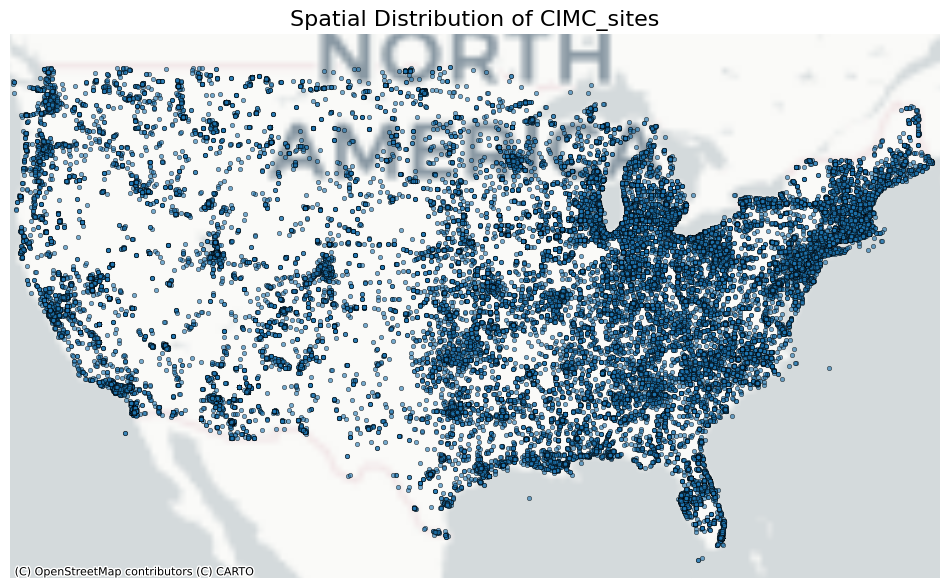

In [ ]:
layer_name = 'CIMC_sites'

print(f"\n {'-'*20}EDA for Layer:  {layer_name}{'-'*20}")

#Read layer
cimc_gdf = gpd.read_file(gdb_path, layer = layer_name)

cimc_gdf = classify_sites(cimc_gdf)
layer_summary(cimc_gdf)
plot_spatial_distribution(cimc_gdf, title = f'Spatial Distribution of {layer_name}')

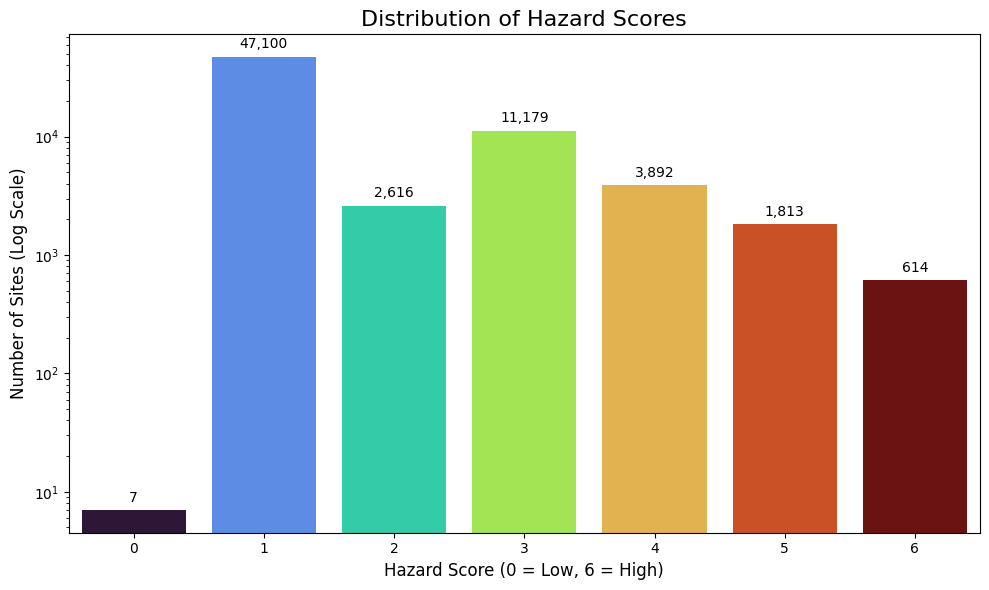

In [ ]:
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(
    x=cimc_gdf['Hazard_Score'],
    palette='turbo', 
    hue=cimc_gdf['Hazard_Score'], 
    legend=False
)

ax1.set_title('Distribution of Hazard Scores', fontsize=16)
ax1.set_xlabel('Hazard Score (0 = Low, 6 = High)', fontsize=12)
ax1.set_ylabel('Number of Sites (Log Scale)', fontsize=12)
ax1.set_yscale('log') 

# Add count labels
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{int(height):,}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.tight_layout()
plt.show()

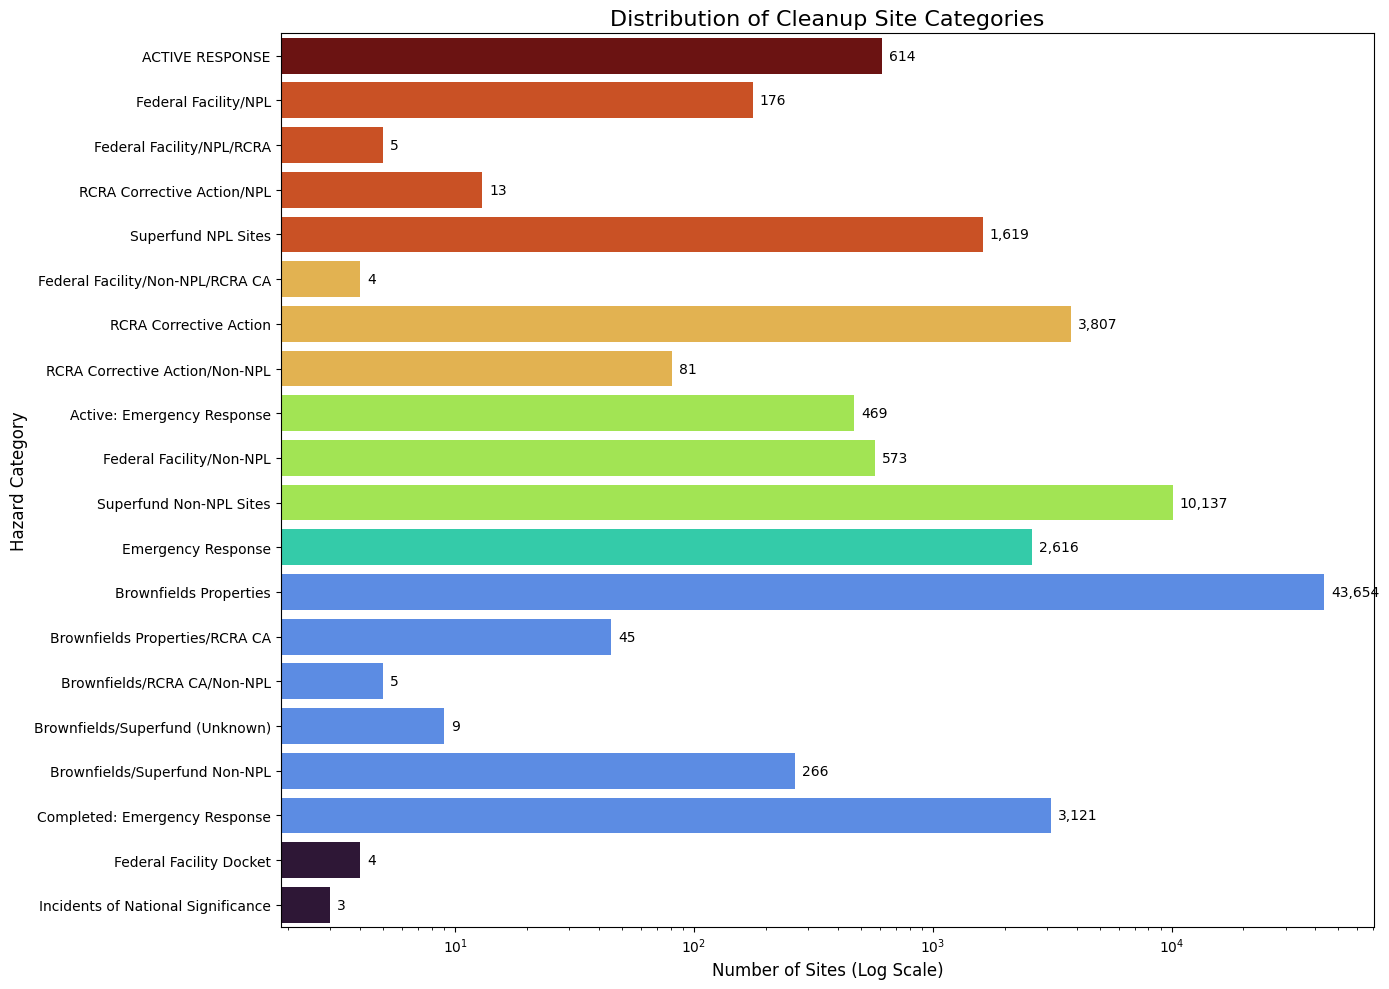

In [ ]:
plt.figure(figsize=(14, 10))
    
# Sort categories by their score, then by count
category_order = cimc_gdf.sort_values(
    by=['Hazard_Score', 'Hazard_Category'], 
    ascending=[False, True]
)['Hazard_Category'].unique()

ax2 = sns.countplot(
    y=cimc_gdf['Hazard_Category'],
    order=category_order,
    palette='turbo',
    hue=cimc_gdf['Hazard_Score'], 
    legend=False
)

ax2.set_title('Distribution of Cleanup Site Categories', fontsize=16)
ax2.set_xlabel('Number of Sites (Log Scale)', fontsize=12)
ax2.set_ylabel('Hazard Category', fontsize=12)
ax2.set_xscale('log')

# Add count labels
for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        ax2.annotate(f'{int(width):,}',
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

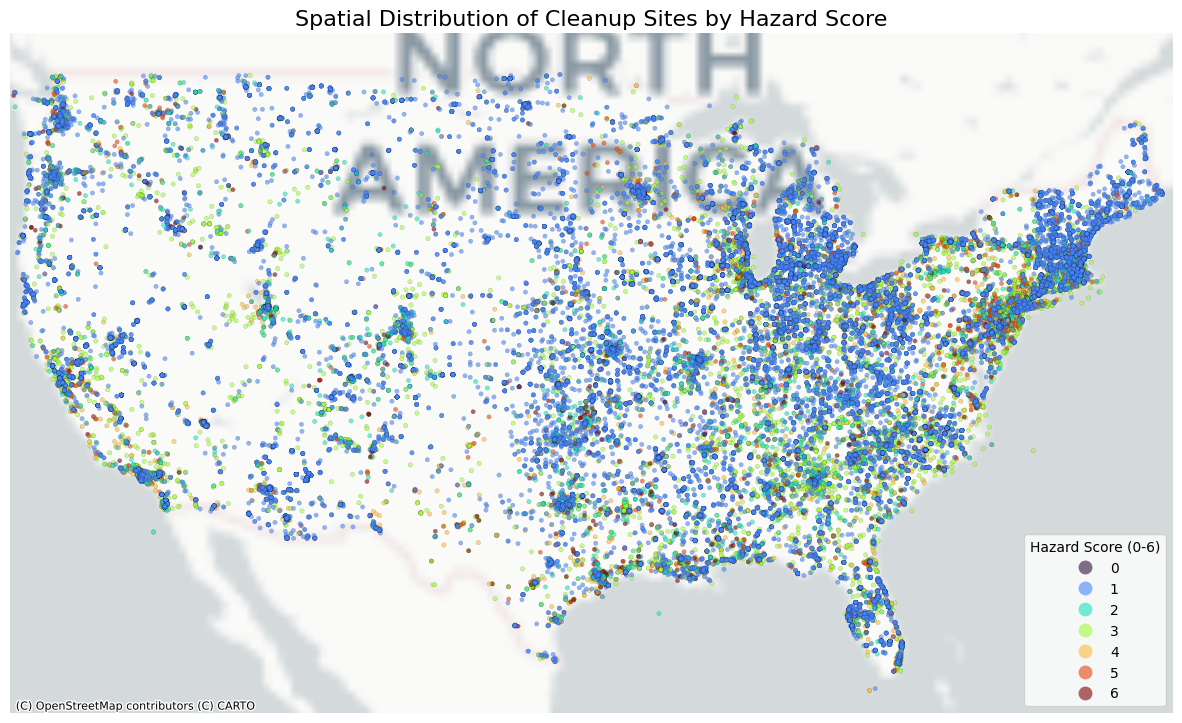

In [ ]:
gdf_web_mercator = cimc_gdf.to_crs(epsg=3857)
title='Spatial Distribution of Cleanup Sites by Hazard Score'

# Main plot
ax = gdf_web_mercator.plot(
    figsize=(15, 10),
    column='Hazard_Score',  
    cmap='turbo',             
    categorical=True,         
    legend=True,              
    legend_kwds={'title': "Hazard Score (0-6)", 'loc': 'lower right'},
    markersize=10,            
    alpha=0.6,                
    edgecolor='k',           
    linewidth=0.1
)

# Add Basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# Limit map to US
xlim = [-1.39e7, -0.74e7] # Longitude
ylim = [2.7e6, 6.5e6]     # Latitude
ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.set_title(title, fontsize=16)
ax.set_axis_off()
plt.show()

In [ ]:
cimc_gdf.to_csv('Data/CIMC_Sites_Hazard_Score.csv', index= False)

In [ ]:
filename = 'CIMC_Sites_Hazard_Score.gpkg'
cimc_gdf.to_file(filename, driver = "GPKG")

### CIMC Sites Alternative Names

In [ ]:
layer_name = 'CIMC_Sites_Alternative_Names'
print(f"\n {'-'*20}EDA for Layer:  {layer_name}{'-'*20}")

#Read layer
layer_gdf = gpd.read_file(gdb_path, layer = layer_name)

layer_summary(layer_gdf)
plot_spatial_distribution(layer_gdf, title = f'Spatial Distribution of {layer_name}')


 --------------------EDA for Layer:  CIMC_Sites_Alternative_Names--------------------
----- Layer Summary -----
Shape (Rows, Columns)
(221228, 5)
Data columns & types
Index(['Field1', 'REGISTRY_ID', 'PRIMARY_NAME', 'PGM_SYS_ACRNM',
       'ALTERNATIVE_NAME'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221228 entries, 0 to 221227
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Field1            221228 non-null  int32 
 1   REGISTRY_ID       221228 non-null  object
 2   PRIMARY_NAME      221212 non-null  object
 3   PGM_SYS_ACRNM     118379 non-null  object
 4   ALTERNATIVE_NAME  221228 non-null  object
dtypes: int32(1), object(4)
memory usage: 7.6+ MB


,Field1,REGISTRY_ID,PRIMARY_NAME,PGM_SYS_ACRNM,ALTERNATIVE_NAME
0,0,110070789457,City-Owned Parking Lot,None,City-Owned Parking Lot
1,1,110071089150,119 Gulf Street,None,119 Gulf Street
2,2,110071089151,121 Gulf Street,None,121 Gulf Street
3,3,110071089512,15001 Euclid Ave. Vacant Auto Repair,None,15001 Euclid Ave. Vacant Auto Repair
4,4,110071089515,16201 Euclid Ave .Vacant Car Wash/Gas Station,None,16201 Euclid Ave .Vacant Car Wash/Gas Station



 --- Descriptive Stats ---
              Field1
count  221228.000000
mean   110613.500000
std     63863.167014
min         0.000000
25%     55306.750000
50%    110613.500000
75%    165920.250000
max    221227.000000

 ----- Plotting Spatial Distribution of CIMC_Sites_Alternative_Names -----
GeoDataFrame is empty or missing a geometyry column. Skipping plot.


# Brownsfields Grants


 --------------------EDA for Layer:  Brownfields_Grant_Jurisdictions--------------------
----- Layer Summary -----
Shape (Rows, Columns)
(2218, 42)
Data columns & types
Index(['JURISDICTION_ID', 'JURISDICTION_TYPE', 'JOB_G', 'JOB_P', 'ASSESS_G',
       'ASSESS_P', 'CLEANUP_G', 'RLF_G', 'RLF_P', 'ST_TRIBE_G',
       'JURISDICTION_NAME', 'MAP_ORDER', 'MAP_CODE', 'NUMPOLYS', 'VE_CENTER',
       'VE_BB', 'VE_DESC', 'TBA_G', 'MP_G', 'VE_JTGRANTS', 'VE_JTPILOTS',
       'VE_ASSESSGRANTS', 'VE_ASSESSPILOTS', 'VE_CLEANUPGRANTS',
       'VE_RLFGRANTS', 'VE_128AGRANTS', 'VE_TBAGRANTS', 'VE_MPGRANTS',
       'VE_RLFPILOTS', 'STATE_CODE', 'COUNTY', 'AWP_G', 'VE_AWPGRANTS',
       'VE_128APGRANTS', 'ST_TRIBE_P', 'SHOWCASE', 'VE_SHOWCASE',
       'CONGRESSIONAL_DIST', 'SHAPE_WKT', 'Shape_Length', 'Shape_Area',
       'geometry'],
      dtype='object')
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 42 columns):
 #   Column              Non-Null 

d:\Documents\Important\Grad School\OMSA\CSE 6242 - Data and Visual Analytics\Final Project\myenv\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


,JURISDICTION_ID,JURISDICTION_TYPE,JOB_G,JOB_P,ASSESS_G,ASSESS_P,CLEANUP_G,RLF_G,RLF_P,ST_TRIBE_G,...,VE_AWPGRANTS,VE_128APGRANTS,ST_TRIBE_P,SHOWCASE,VE_SHOWCASE,CONGRESSIONAL_DIST,SHAPE_WKT,Shape_Length,Shape_Area,geometry
0,86071,CITY,N,N,Y,Y,Y,N,N,N,...,,,N,N,,MN-05,,85532.837908,2.973083e+08,"MULTIPOLYGON (((-10389386.267 5612847.351, -10..."
1,91347,CITY,N,N,N,N,N,Y,Y,N,...,1 AREA-WIDE PLANNING GRANT(S)<br />,,N,N,,"CO-04,CO-06,CO-01",,540985.420630,6.772517e+08,"MULTIPOLYGON (((-11634839.22 4829449.044, -116..."
2,103182,CITY,N,N,N,N,Y,N,N,N,...,,,N,N,,"NH-02,NH-01",,20971.098527,1.435396e+07,"MULTIPOLYGON (((-7972828.483 5380269.452, -797..."
3,103213,CITY,N,N,Y,N,Y,N,N,N,...,,,N,N,,NH-02,,13575.747599,5.982657e+06,"MULTIPOLYGON (((-8063466.844 5323421.373, -806..."
4,83374,CITY,N,N,Y,N,N,N,N,N,...,,,N,N,,MI-03,,68844.990962,1.199329e+08,"MULTIPOLYGON (((-9547237.457 5289594.663, -954..."



 --- Geospatial Info ---
Geometry Type: ['MultiPolygon']
CRS: EPSG:3857

 --- Descriptive Stats ---
       JURISDICTION_ID    MAP_ORDER     NUMPOLYS  Shape_Length    Shape_Area
count     2.218000e+03  2218.000000  2218.000000  2.218000e+03  2.218000e+03
mean      3.075974e+05     4.604148     2.253381  3.690165e+05  2.924692e+10
std       5.795449e+05     1.309285    12.634617  1.548889e+06  3.596901e+11
min       5.800000e+01     1.000000     1.000000  9.939441e+01  5.756861e+02
25%       6.377500e+04     3.000000     1.000000  3.518909e+04  2.665680e+07
50%       1.247525e+05     5.000000     1.000000  9.830585e+04  1.248581e+08
75%       1.979328e+05     5.000000     1.000000  3.062426e+05  2.548794e+09
max       2.001457e+06     6.000000   477.000000  3.603583e+07  9.015681e+12

 ----- Plotting Spatial Distribution of Brownfields_Grant_Jurisdictions -----


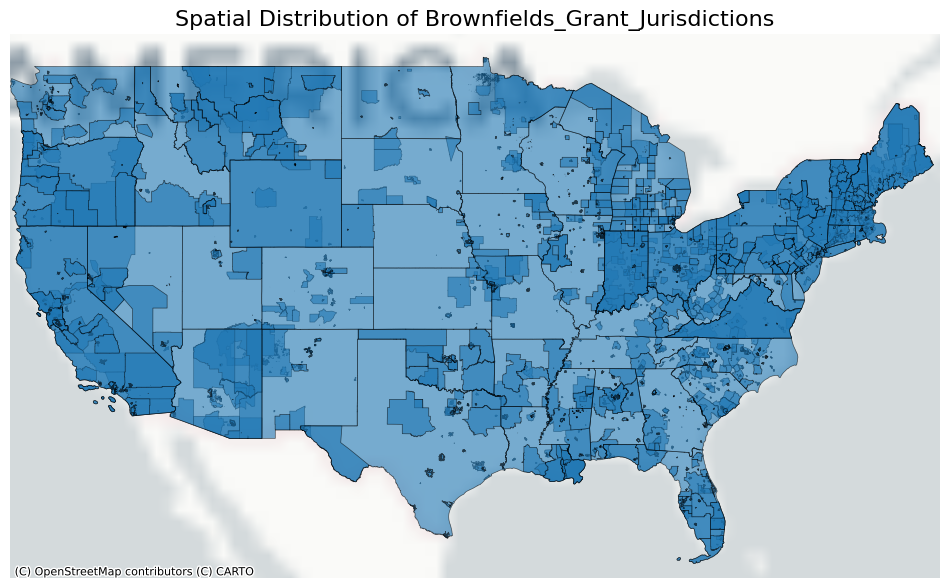

In [ ]:
layer_name = 'Brownfields_Grant_Jurisdictions'
print(f"\n {'-'*20}EDA for Layer:  {layer_name}{'-'*20}")

#Read layer
layer_gdf = gpd.read_file(gdb_path, layer = layer_name)

layer_summary(layer_gdf)
plot_spatial_distribution(layer_gdf, title = f'Spatial Distribution of {layer_name}')


In [ ]:
layer_name = 'Brownfields_Grant_Data'
print(f"\n {'-'*20}EDA for Layer:  {layer_name}{'-'*20}")

#Read layer
layer_gdf = gpd.read_file(gdb_path, layer = layer_name)

layer_summary(layer_gdf)
plot_spatial_distribution(layer_gdf, title = f'Spatial Distribution of {layer_name}')


 --------------------EDA for Layer:  Brownfields_Grant_Data--------------------
----- Layer Summary -----
Shape (Rows, Columns)
(7398, 8)
Data columns & types
Index(['Field1', 'JURISDICTION_ID', 'GRANT_ID', 'GRANT_STATUS', 'GRANT_TYPE',
       'PRIMARY_JURISDICTION', 'RECIPIENT_NAME', 'COOPERATIVE_AGREEMENT_PC'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7398 entries, 0 to 7397
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Field1                    7398 non-null   int32 
 1   JURISDICTION_ID           7398 non-null   int32 
 2   GRANT_ID                  7398 non-null   int32 
 3   GRANT_STATUS              7398 non-null   object
 4   GRANT_TYPE                7382 non-null   object
 5   PRIMARY_JURISDICTION      7398 non-null   object
 6   RECIPIENT_NAME            7398 non-null   object
 7   COOPERATIVE_AGREEMENT_PC  7345 non-null   object
dtypes: int32(3)

,Field1,JURISDICTION_ID,GRANT_ID,GRANT_STATUS,GRANT_TYPE,PRIMARY_JURISDICTION,RECIPIENT_NAME,COOPERATIVE_AGREEMENT_PC
0,0,132231,69603947,Open,RLF GRANT(S),Y,City of Toledo,BF00E02009
1,1,190882,69602341,Closed,ASSESSMENT GRANT(S),Y,City of Manitowoc,BF00E01529
2,2,103754,69601851,Closed,CLEANUP GRANT(S),Y,Camden Redevelopment Agency,BF96281315
3,3,103754,69601852,Closed,CLEANUP GRANT(S),Y,Camden Redevelopment Agency,BF96281415
4,4,192964,69603883,Closed,ASSESSMENT GRANT(S),Y,City of Casper,BF96849701



 --- Descriptive Stats ---
            Field1  JURISDICTION_ID      GRANT_ID
count  7398.000000     7.398000e+03  7.398000e+03
mean   3698.500000     2.419880e+05  6.804135e+07
std    2135.762978     4.665627e+05  5.750365e+06
min       0.000000     5.800000e+01  3.356870e+07
25%    1849.250000     6.997400e+04  6.959894e+07
50%    3698.500000     1.331160e+05  6.960083e+07
75%    5547.750000     1.979370e+05  6.960495e+07
max    7397.000000     2.001457e+06  6.960943e+07

 ----- Plotting Spatial Distribution of Brownfields_Grant_Data -----
GeoDataFrame is empty or missing a geometyry column. Skipping plot.


### 